#Objetivo e introducción

El objetivo del proyecto consiste en analizar las ventas de un negocio de comercio electrónico para comprender el comportamiento temporal de las ventas, identificar patrones de compra de los clientes, construir un dashboard interactivo para la visualización de indicadores y proponer posibles acciones que contribuyan a la toma de decisiones comerciales.

Para la limpeza de los datos y el análisis posterior del negocio, se utilizó como herramienta Python, y para la elaboración del dashboard se utilizó Power BI, utilizando los datos normalizados previamente en Python.

Este análisis se realizó utilizando únicamente la información disponible en el dataset. Variables como categorías de productos, costos, márgenes de ganancia, canal de venta o información demográfica de los clientes permitirían profundizar considerablemente el análisis.

Página donde fue extraida la base de datos:

https://www.kaggle.com/datasets/umerkk12/online-retail-business

In [53]:
import pandas as pd
import numpy as np
import seaborn.objects as so

In [54]:
df = pd.read_csv('OnlineRetail.csv',encoding='latin1')

In [55]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France


#Limpieza

Antes de realizar cualquier análisis, resulta fundamental evaluar y preparar la calidad de los datos. Un conjunto de datos con valores faltantes, registros duplicados o inconsistencias puede afectar la interpretación de los resultados y conducir a conclusiones erróneas. Por este motivo, en esta sección se analizan las principales características del dataset y se aplican las transformaciones necesarias para obtener una base de datos consistente y adecuada para el análisis exploratorio y la construcción del dashboard.

##Renombre de columnas

In [56]:
columnas = {
    'InvoiceNo': 'codigo_factura',
    'StockCode': 'codigo_producto',
    'Description': 'descripcion',
    'Quantity': 'cantidad',
    'InvoiceDate': 'fecha_factura',
    'UnitPrice': 'precio_unitario',
    'CustomerID': 'codigo_cliente',
    'Country': 'pais'
}
df = df.rename(columns=columnas)

##Nulos y problemas de tipo

In [57]:
df.isna().sum()

,0
codigo_factura,0
codigo_producto,0
descripcion,1454
cantidad,0
fecha_factura,0
precio_unitario,0
codigo_cliente,135080
pais,0


In [64]:
clientes_desconocidos = df["codigo_cliente"].isna().sum()
productos_sin_desc = df["descripcion"].isna().sum()

print('Cantidad de filas con clientes desconocidos:',round(clientes_desconocidos/len(df)*100,2),'%')
print('Cantidad de filas sin descripción:',round(productos_sin_desc/len(df)*100,2),'%')

Cantidad de filas con clientes desconocidos 24.93 %
Cantidad de filas sin descripción 0.27 %


El 24.93% de las transacciones no tiene cliente identificado. En lugar de eliminar esas filas, se optó por conservarlas bajo la etiqueta 'Desconocido', ya que representan una porción significativa del volumen de ventas
Lo mismo para descripcion, reemplazando por "No tiene", aunque el porcentaje de filas con este problema es mucho menor que los clientes no identificados.

In [6]:
df["codigo_cliente"] = (
    df["codigo_cliente"]
    .fillna(-1)
    .astype(int)
    .astype(str)
    .replace("-1", "Desconocido")
)
df["descripcion"] = df["descripcion"].fillna("No tiene")

La columna fecha_factura fue transformada a formato fecha para evitar posibles errores.

In [7]:
df['fecha_factura'] = pd.to_datetime(df['fecha_factura'],format='%d-%m-%Y %H:%M')

##Borrado de filas con cantidad y precio unitario negativos

Se eliminaron las filas con cantidad y precio unitario negativos o cero, dado que esto podria representar una corrección, como por ejemplo una devolución, y no por una venta real. De esta manera se conservan los datos de cantidad y precio unitario positivos.

Se guarda el número de filas eliminadas para realizar más adelante un cálculo de la información perdida en este proceso.

In [8]:
longitud_df_original = len(df)
filas_eliminadas_1 = len(df[(df["cantidad"]<=0) | (df["precio_unitario"]<=0)])

In [9]:
print("Longitud del df:",len(df))
print("Cantidad de filas con precio unitario y/o cantidad negativos:",len(df[(df["cantidad"]<=0) | (df["precio_unitario"]<=0)]))

Longitud del df: 541909
Cantidad de filas con precio unitario y/o cantidad negativos: 11805


In [10]:
df = df[(df["cantidad"]>0) & (df["precio_unitario"]>0)]

##Filas repetidas

Existen filas repetidas?

In [11]:
apariciones = df.value_counts()
resumen = apariciones.sort_values()
resumen.value_counts().sort_index(ascending=False)

,count
count,
20,1
12,1
8,1
6,6
5,5
4,38
3,235
2,4555
1,520036


Se puede ver que hay un número considerable de filas repetidas, desde una única repetición hasta 20.

La explicación de tener filas repetidas se puede deber a dos causas, y cada una conllevaría un tratamiento distinto:

La primera es debido a que se registró dos veces la misma transacción. Es la teoría que se asume, y la solución podría ser borrar las repeticiones, dejando únicamente la fila original.

La otra explicación, que no fue considerada debido a la falta de información, es que por alguna razón no se pudo registrar la transacción en una única fila, y se tuvo que separar en dos o más, y la unión de esas filas daría como resultado la cantidad total de ese producto comprado. La solución sería mantener las filas repetidas.

Dado que no se dispone de información adicional para distinguir ambos casos, se optó por la primera interpretación y se eliminaron las filas duplicadas.

Nuevamente fue conservado el numero de filas eliminadas en este procedimiento.

In [12]:
filas_eliminadas_2 = len(df[df.duplicated()])

In [13]:
print("Cantidad de filas duplicadas que serán eliminadas:",len(df[df.duplicated()]))

Cantidad de filas duplicadas que serán eliminadas: 5226


In [14]:
df = df.drop_duplicates()

##Cantidad de filas eliminadas

Se calcula el porcentaje de filas eliminadas como la suma entre ambas cantidades de filas eliminadas (por repetición y por valores negativos), y ese resultado fue dividido por la longitud original del DataFrame, multiplicado por 100.

In [15]:
print('Se perdió un:', round((filas_eliminadas_1 + filas_eliminadas_2)/longitud_df_original*100,2), '% de los datos')

Se perdió un: 3.14 % de los datos


##Creacion de nuevas variables

Para poder hacer un estudio más exhaustivo, se crearon nuevas columnas con información extraida de la columna fecha_factura.

In [16]:
df["año"] = df["fecha_factura"].dt.year
df["mes"] = df["fecha_factura"].dt.month
df["nombre_mes"] = df["fecha_factura"].dt.month_name()
df["dia"] = df["fecha_factura"].dt.day
df["nombre_dia_semana"] = df["fecha_factura"].dt.day_name()
df["numero_dia_semana"] = df["fecha_factura"].dt.weekday + 1
df['hora'] = df['fecha_factura'].dt.hour
df['minuto'] = df['fecha_factura'].dt.minute

Tambien fue creada la columna ingreso, que se calcula como el resultado del producto entre la columna cantidad y precio_unitario.

In [17]:
df["ingreso"]=df['cantidad']*df['precio_unitario']

Resultado final del DataFrame luego de las modificaciones:

In [18]:
df.head()

,codigo_factura,codigo_producto,descripcion,cantidad,fecha_factura,precio_unitario,codigo_cliente,pais,año,mes,nombre_mes,dia,nombre_dia_semana,numero_dia_semana,hora,minuto,ingreso
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,December,1,Wednesday,3,8,26,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,December,1,Wednesday,3,8,26,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,December,1,Wednesday,3,8,26,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,December,1,Wednesday,3,8,26,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,December,1,Wednesday,3,8,26,20.34


Esta información normalizada o "limpia", será utilizada para:

a) Exportarla y crear un csv nuevo llamado ventas_limpio, y elaborar un Dashboard en Power BI.

b) Realizar un análisis del comportamiento de los clientes.

In [19]:
#df.to_csv("ventas_limpio.csv", index=False, encoding="latin1")

#from google.colab import files
#files.download("ventas_limpio.csv")

#Análisis de clientes

El siguiente análisis se enfoca en el comportamiento de los clientes, y se realizan los siguientes estudios:

- Tasa de retención.

- Segmentación mediante el modelo RFM, ampliamente utilizado en marketing para identificar el valor de cada cliente.

- Distribución de ingresos para distintos porcentajes de clientes.

- Distribución de cantidad de compras.


##Clientes que vuelven a comprar

Se calcula el porcentaje de clientes que vuelven a comprar, dando una métrica que indica la retención de clientes.

In [20]:
cantidad_compras_cliente = df.groupby("codigo_cliente")["codigo_factura"].nunique().sort_values(ascending=False)
cantidad_compras_cliente.name = "cantidad_compras"
clientes_vuelven = cantidad_compras_cliente[cantidad_compras_cliente > 1]

cantidad_clientes = len(cantidad_compras_cliente)
cantidad_clientes_vuelven = len(clientes_vuelven)
porcentaje_clientes_vuelven = np.round(cantidad_clientes_vuelven*100/cantidad_clientes,2)

print("Cantidad de clientes:", cantidad_clientes)
print("Cantidad de clientes que vuelven a comprar:", cantidad_clientes_vuelven)
print("Porcentaje de clientes que vuelven a comprar:", porcentaje_clientes_vuelven,"%")

Cantidad de clientes: 4339
Cantidad de clientes que vuelven a comprar: 2846
Porcentaje de clientes que vuelven a comprar: 65.59 %


##Segmentación de clientes mediante RFM (Recency, Frequency, Monetary)

Se realiza un estudio RFM, que combina y condensa información relevante de los clientes en Recency, indicando la última compra; Frequency, como la cantidad de compras; y por último Monetary, que expresa el monto total gastado por el cliente.

Este análisis permite estudiar el comportamiento de los clientes considerando tres dimensiones, y es ampliamente utilizado en marketing para segmentar clientes según su comportamiento.

###Recency

In [21]:
fecha_mas_reciente = df['fecha_factura'].max()
df['ultima_compra'] = fecha_mas_reciente - df['fecha_factura']
recency = df.groupby("codigo_cliente")["ultima_compra"].min().sort_values(ascending=False)
recency

,ultima_compra
codigo_cliente,
18074,373 days 02:57:00
13747,373 days 02:13:00
12791,373 days 01:23:00
17908,373 days 01:05:00
16583,373 days 00:47:00
...,...
17581,0 days 00:29:00
13777,0 days 00:25:00
15804,0 days 00:19:00


###Frequency

In [22]:
frequency = cantidad_compras_cliente.copy()
frequency

,cantidad_compras
codigo_cliente,
Desconocido,1428
12748,209
14911,201
17841,124
13089,97
...,...
18222,1
18224,1
18227,1


###Monetary

In [23]:
monetary = df.groupby("codigo_cliente")["ingreso"].sum().sort_values(ascending=False)
monetary

,ingreso
codigo_cliente,
Desconocido,1754901.91
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
...,...
16878,13.30
17956,12.75
16454,6.90


###Análisis RFM agrupando los valores de recency

Se creó el DataFrame rfm, que unifica toda la información obtenida en las secciones anteriores.

In [24]:
recency.name = "recency"
frequency.name = "frequency"
monetary.name = "monetary"

rfm = pd.concat([recency, frequency, monetary], axis=1).sort_values("frequency",ascending=False)

rfm

,recency,frequency,monetary
codigo_cliente,,,
Desconocido,0 days 02:24:00,1428,1754901.91
12748,0 days 00:30:00,209,33053.19
14911,0 days 20:56:00,201,143711.17
17841,1 days 00:43:00,124,40519.84
13089,2 days 03:48:00,97,58762.08
...,...,...,...
15165,372 days 22:47:00,1,487.75
17643,372 days 22:12:00,1,101.55
16274,372 days 21:15:00,1,351.75


Fue creada una nueva columna "segmento_recency" para categorizar a los clientes según su ultima compra, tomando como referencia los cuartiles.

In [26]:
q25 = rfm["recency"].quantile(0.25)
q50 = rfm["recency"].quantile(0.50)
q75 = rfm["recency"].quantile(0.75)

rfm["segmento_recency"] = pd.cut(
    rfm["recency"],
    bins=[
        pd.Timedelta(days=-1),
        q25,
        q50,
        q75,
        rfm["recency"].max()
    ],
    labels=[
        "Muy reciente",
        "Reciente",
        "En riesgo",
        "Inactivo"
    ])

rfm

,recency,frequency,monetary,segmento_recency
codigo_cliente,,,,
Desconocido,0 days 02:24:00,1428,1754901.91,Muy reciente
12748,0 days 00:30:00,209,33053.19,Muy reciente
14911,0 days 20:56:00,201,143711.17,Muy reciente
17841,1 days 00:43:00,124,40519.84,Muy reciente
13089,2 days 03:48:00,97,58762.08,Muy reciente
...,...,...,...,...
15165,372 days 22:47:00,1,487.75,Inactivo
17643,372 days 22:12:00,1,101.55,Inactivo
16274,372 days 21:15:00,1,351.75,Inactivo


Se visualiza la información RFM, tomando como eje x frequency, en el eje y recency, y coloreado según su segmento de recency.

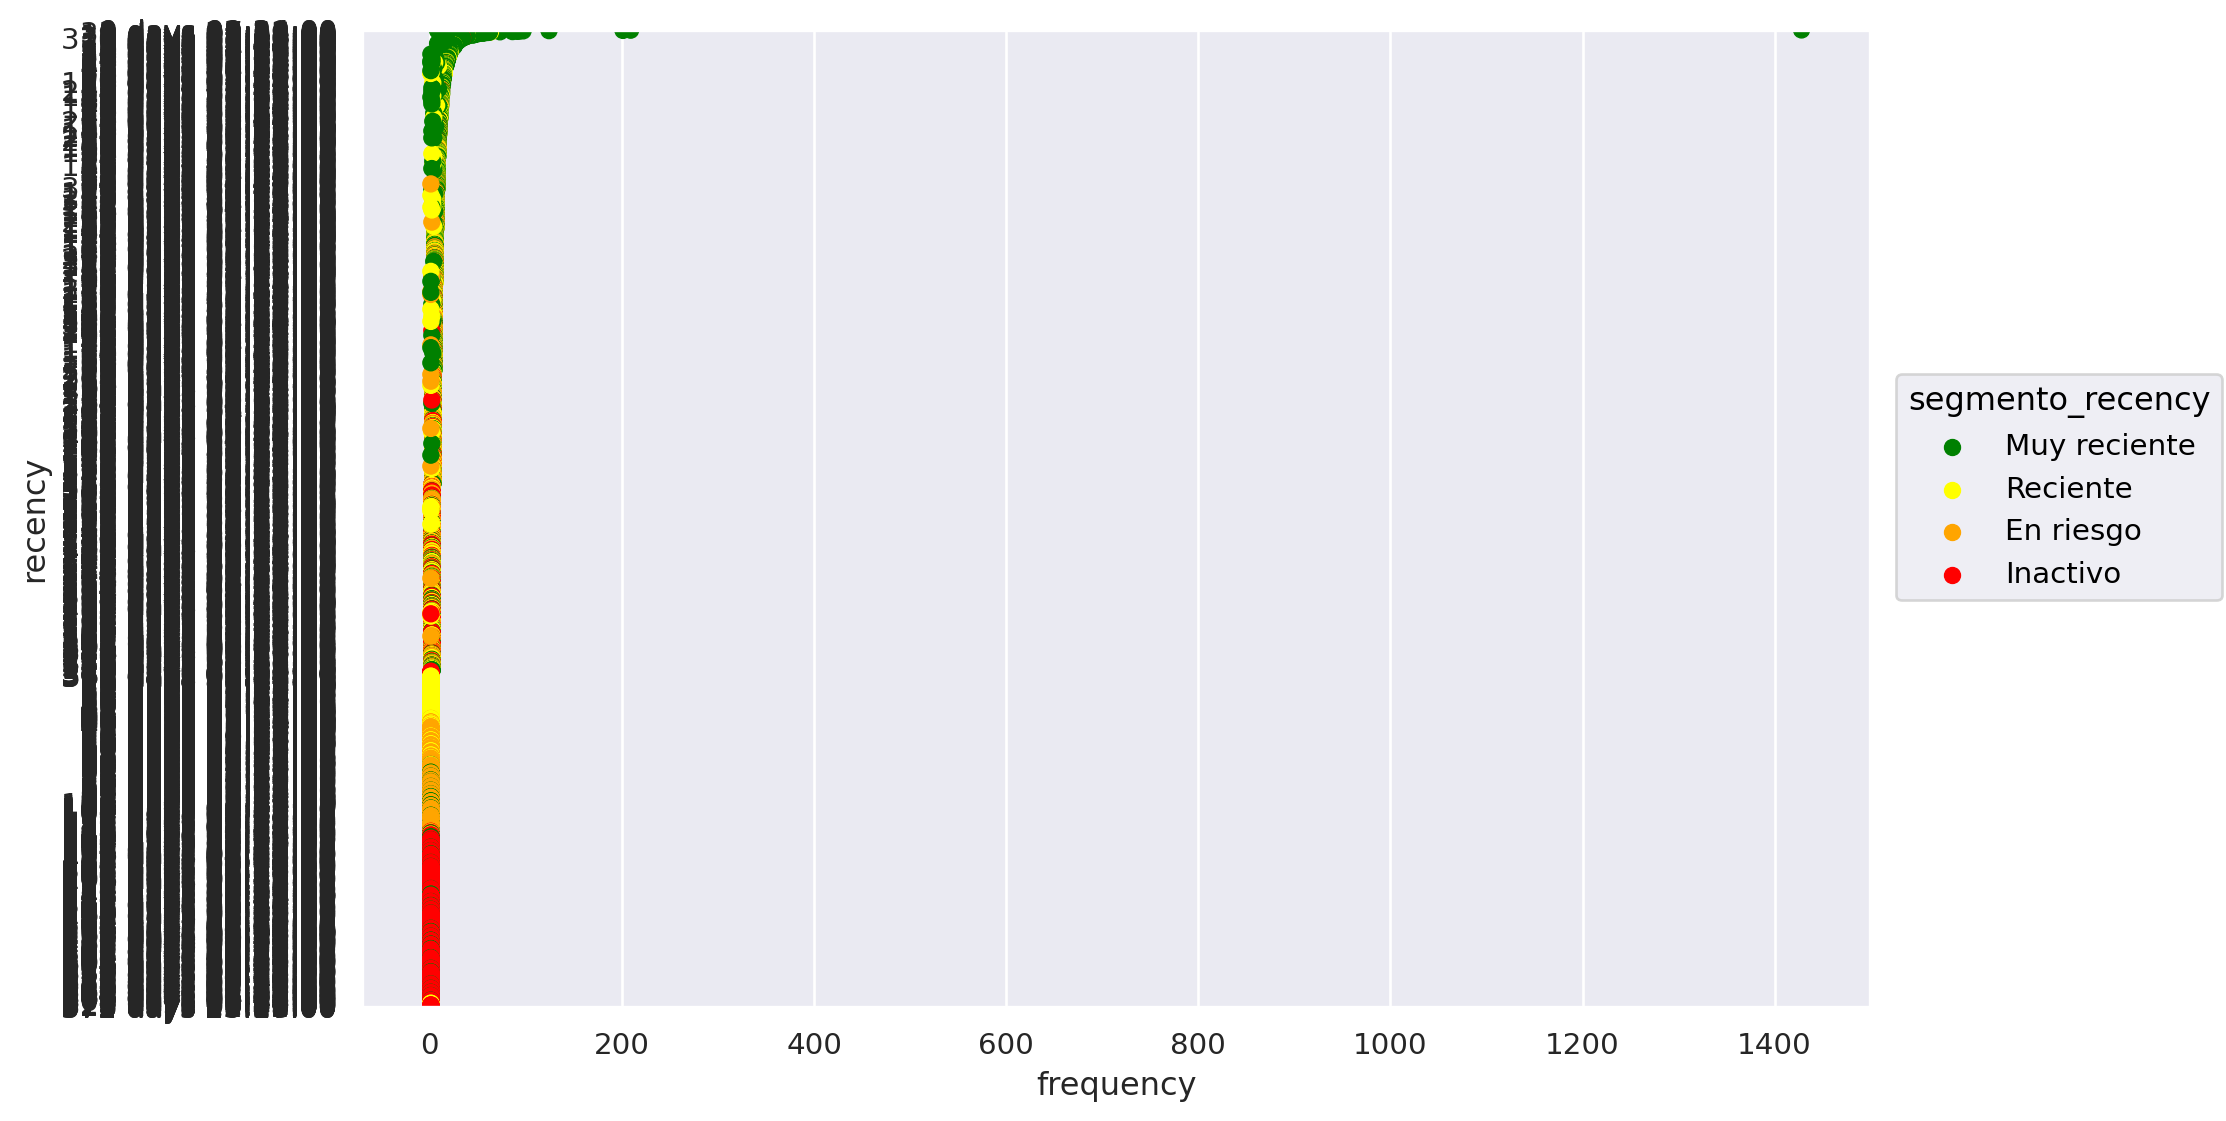

In [27]:
palette = {
    "Muy reciente": "green",
    "Reciente": "yellow",
    "En riesgo": "orange",
    "Inactivo": "red"
    }

(
    so.Plot(data=rfm,x="frequency",y="recency",color="segmento_recency")
    .add(so.Dot())
    .scale(color=palette)
    .layout(size=(10,6))
)

El grafico muestra que hay un outlier muy claro, que son los clientes con código "Desconocido". Se vuelve a graficar expluyendo los clientes desconocidos.

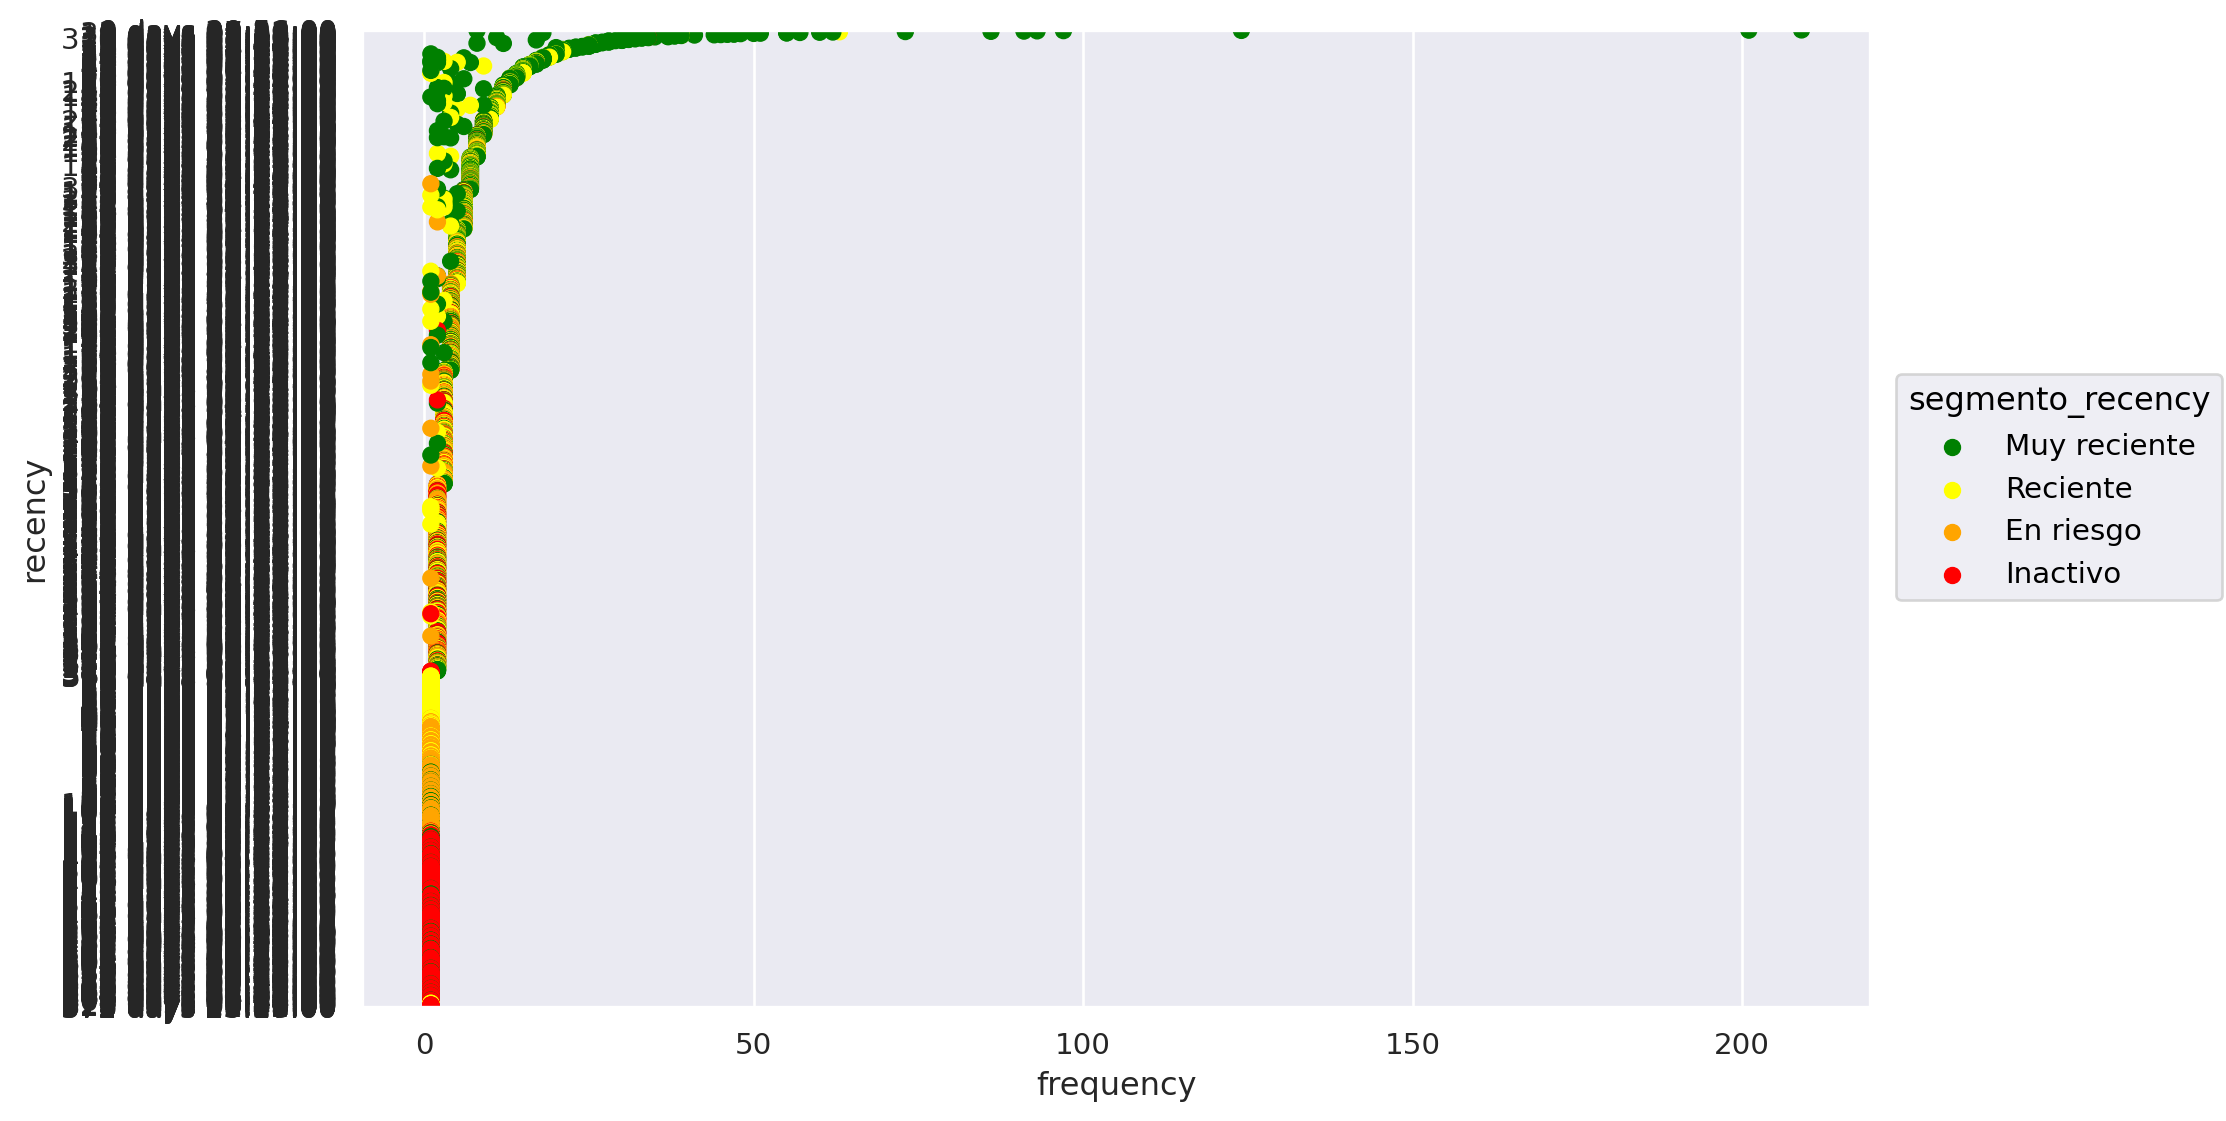

In [28]:
rfm_sin_desconocidos = rfm.iloc[1:,:].copy()

(
    so.Plot(data=rfm_sin_desconocidos,x="frequency",y="recency",color="segmento_recency")
    .add(so.Dot())
    .scale(color=palette)
    .layout(size=(10,6))
)

Dado que tanto frequency como monetary presentan distribuciones muy sesgadas hacia valores bajos, fue aplicada una transformación logarítmica para poder visualizar mejor la estructura de los datos sin que los valores extremos dominen el gráfico.

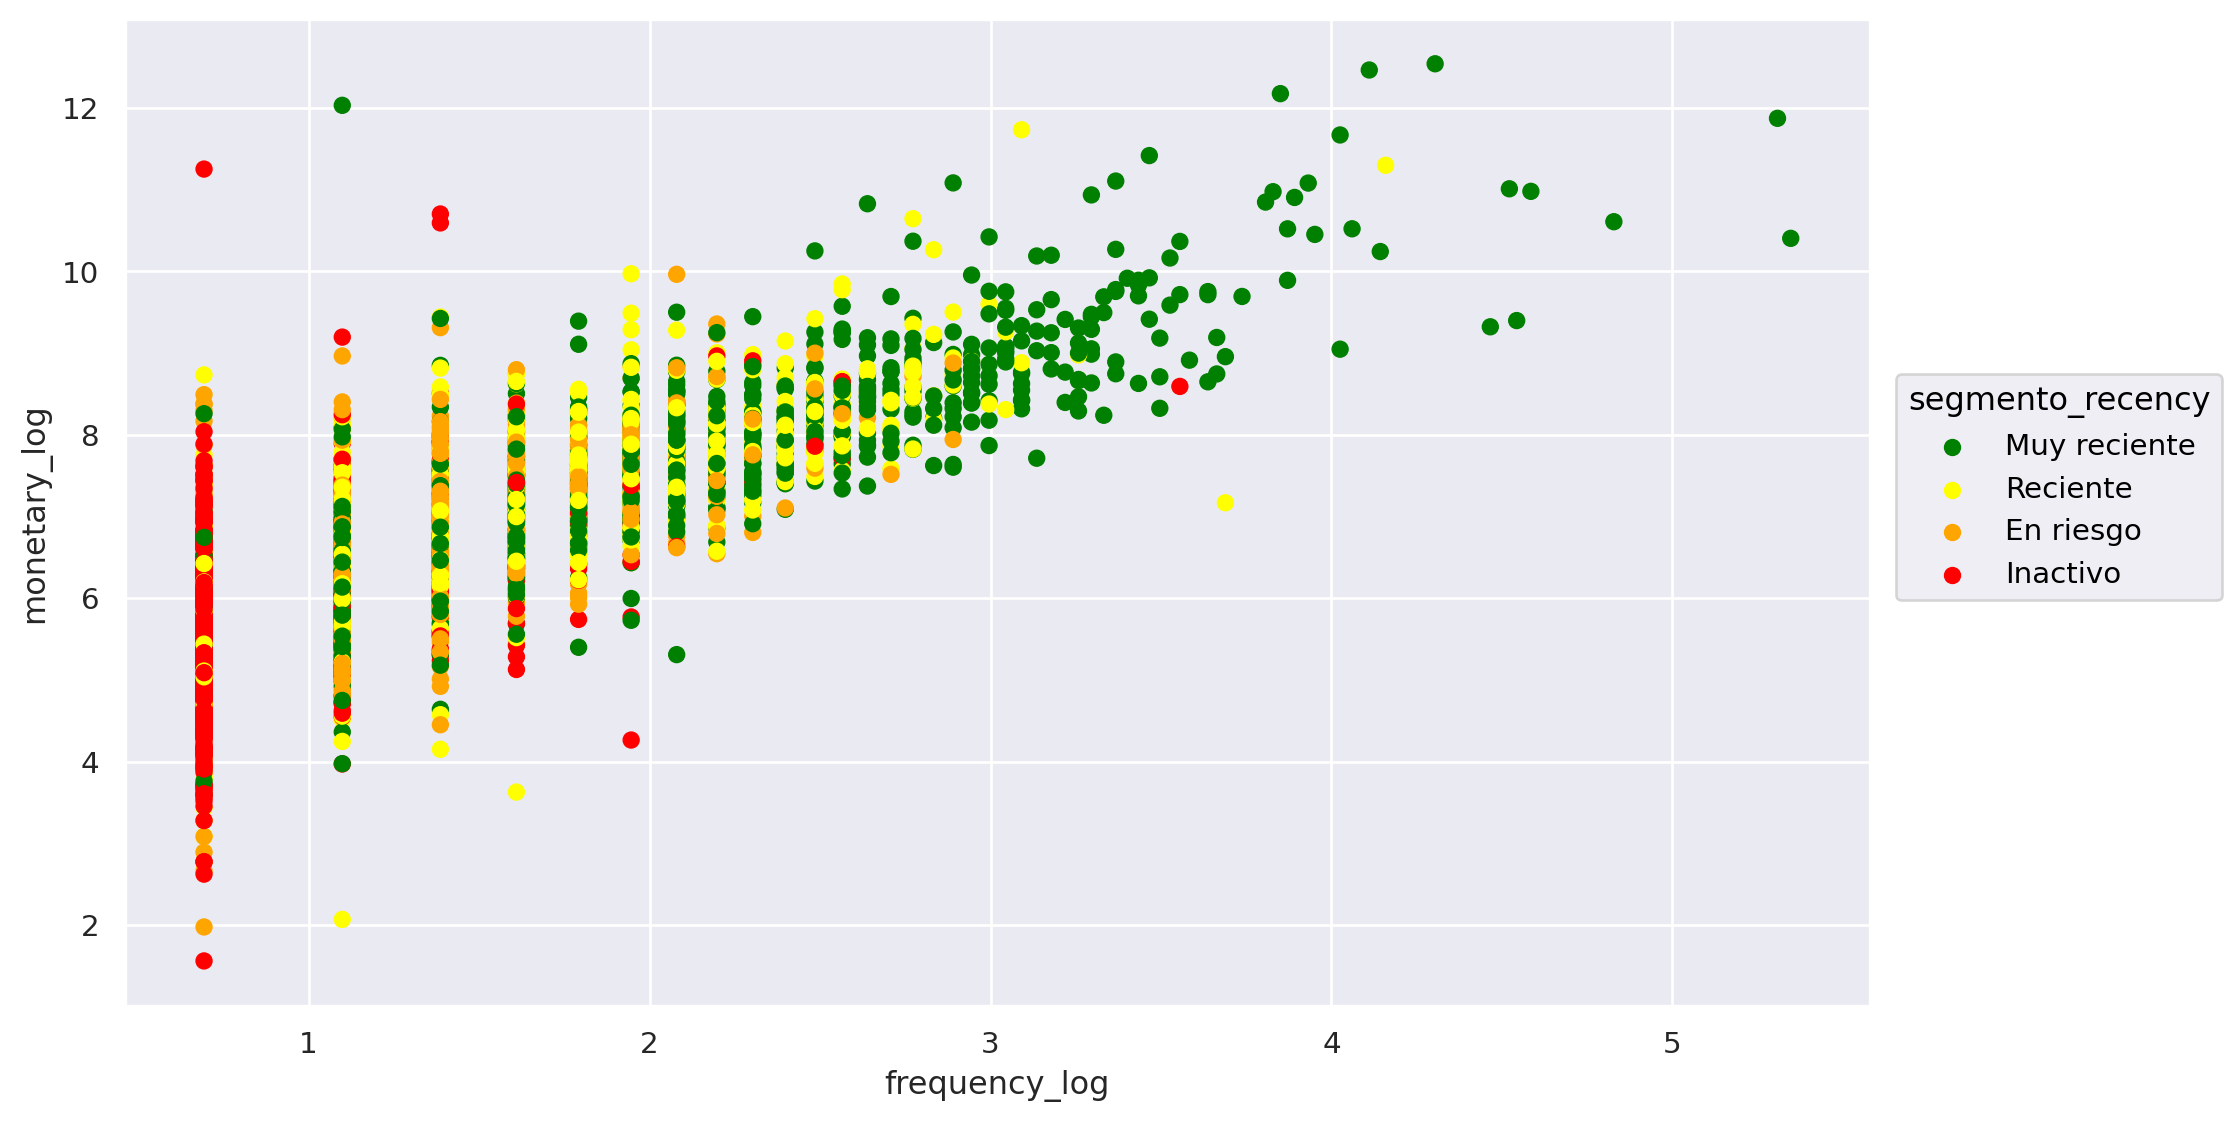

In [29]:
rfm_sin_desconocidos["frequency_log"] = np.log1p(rfm_sin_desconocidos["frequency"])
rfm_sin_desconocidos["monetary_log"] = np.log1p(rfm_sin_desconocidos["monetary"])

(
    so.Plot(rfm_sin_desconocidos,x="frequency_log",y="monetary_log",color="segmento_recency")
    .add(so.Dot())
    .scale(color=palette)
    .layout(size=(10,6))
)

Se observó una fuerte relación positiva entre la frecuencia de compra (Frequency) y el ingreso acumulado generado por el cliente (Monetary). Sin embargo, este resultado era esperable dado que el ingreso total se construye a partir de la suma de todas las compras realizadas.

Para obtener una medida menos dependiente de la cantidad de compras, se definió el ingreso promedio por factura como Monetary/Frequency.

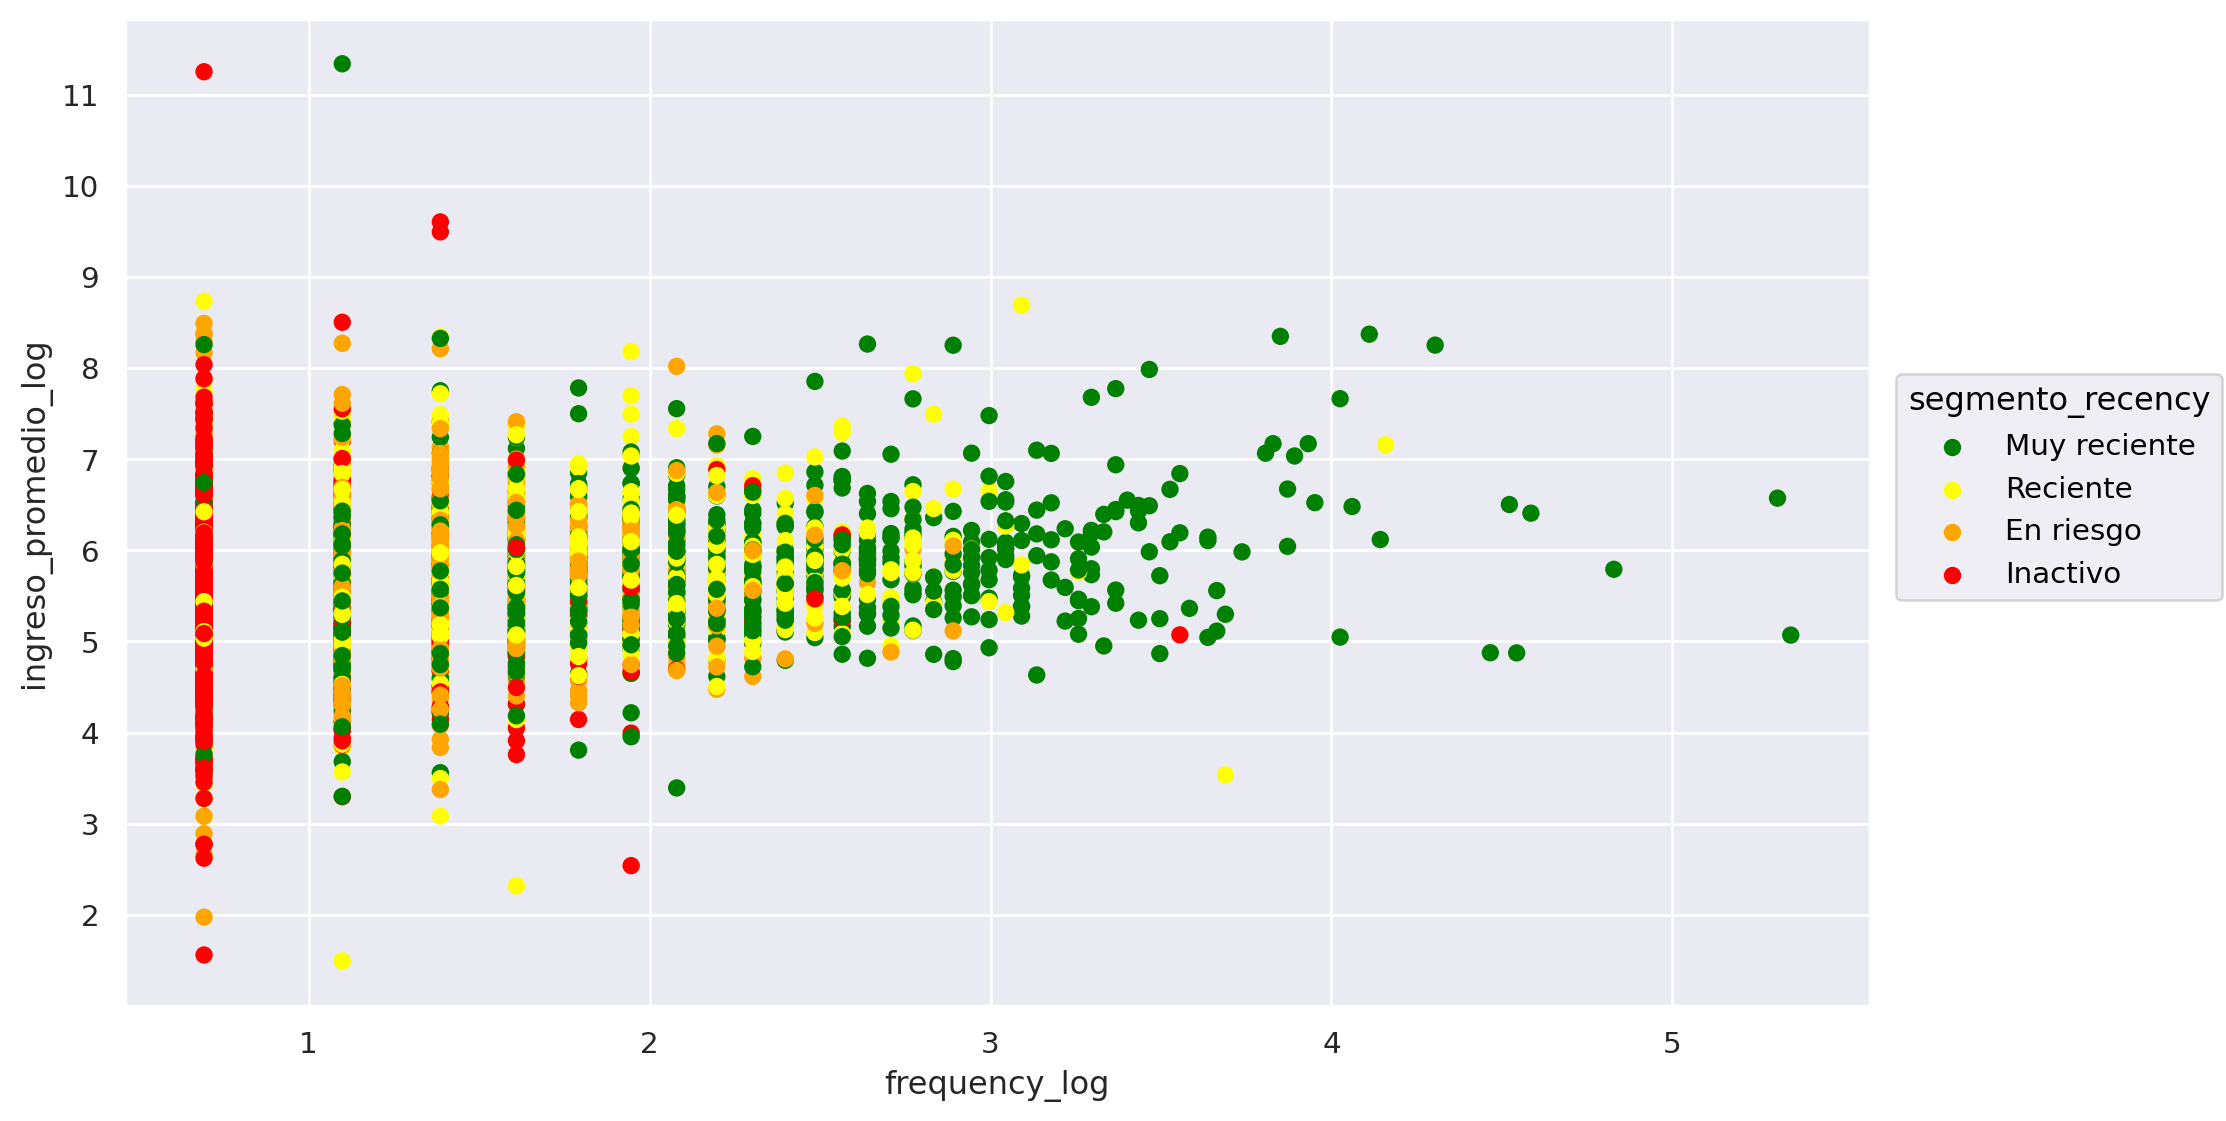

In [30]:
rfm_sin_desconocidos["ingreso_promedio"] = (rfm_sin_desconocidos["monetary"] / rfm_sin_desconocidos["frequency"])
rfm_sin_desconocidos["ingreso_promedio_log"] = np.log1p(rfm_sin_desconocidos["ingreso_promedio"])

(
    so.Plot(rfm_sin_desconocidos,x="frequency_log",y="ingreso_promedio_log",color="segmento_recency")
    .add(so.Dot())
    .scale(color=palette,y=so.Continuous().tick(every=1))
    .layout(size=(10,6))
)

Los clientes con pocas compras presentan una gran dispersión en el ingreso promedio por factura, mientras que los clientes más frecuentes tienden a concentrarse en un rango de gasto más estable.

In [31]:
rfm_sin_desconocidos.groupby("segmento_recency", observed=False)["ingreso_promedio"].agg(
    ["count", "mean", "median", "std"]
).copy()

,count,mean,median,std
segmento_recency,,,,
Muy reciente,1084,473.673077,310.314,2579.995838
Reciente,1085,377.960508,294.855,409.518565
En riesgo,1084,408.595007,313.300,438.734337
Inactivo,1085,410.397644,231.955,2428.515141


No se observan diferencias significativas en el ingreso promedio por factura entre los distintos segmentos de recency.

Los clientes muy recientes, recientes y en riesgo presentan valores similares, mientras que los clientes inactivos muestran un ingreso mediano ligeramente menor, no así el medio.

Sin embargo, la elevada dispersión dentro de cada segmento dificulta identificar una tendencia clara.

###Análisis RFM agrupando los valores de las tres variables

A continuación se extiende el análisis incorporando las tres dimensiones del RFM mediante quintiles, asignando a cada cliente un puntaje del 1 al 5 en recency, frequency y monetary, y combinándolos en segmentos con nombre.

In [32]:
rfm_sin_desconocidos["R"] = pd.qcut(
    rfm_sin_desconocidos["recency"],
    q=5,
    labels=[5,4,3,2,1]
)

rfm_sin_desconocidos["F"] = pd.qcut(
    rfm_sin_desconocidos["frequency"].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

rfm_sin_desconocidos["M"] = pd.qcut(
    rfm_sin_desconocidos["monetary"].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

In [33]:
rfm_sin_desconocidos

,recency,frequency,monetary,segmento_recency,frequency_log,monetary_log,ingreso_promedio,ingreso_promedio_log,R,F,M
codigo_cliente,,,,,,,,,,,
12748,0 days 00:30:00,209,33053.19,Muy reciente,5.347108,10.405904,158.149234,5.069842,5,5,5
14911,0 days 20:56:00,201,143711.17,Muy reciente,5.308268,11.875568,714.980945,6.573654,5,5,5
17841,1 days 00:43:00,124,40519.84,Muy reciente,4.828314,10.609572,326.772903,5.792321,5,5,5
13089,2 days 03:48:00,97,58762.08,Muy reciente,4.584967,10.981269,605.794639,6.408190,5,5,5
14606,0 days 17:22:00,93,12076.15,Muy reciente,4.543295,9.399071,129.851075,4.874060,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...
15165,372 days 22:47:00,1,487.75,Inactivo,0.693147,6.191851,487.750000,6.191851,1,2,3
17643,372 days 22:12:00,1,101.55,Inactivo,0.693147,4.630350,101.550000,4.630350,1,2,1
16274,372 days 21:15:00,1,351.75,Inactivo,0.693147,5.865760,351.750000,5.865760,1,2,2


Se crean categorías segun distitnas combinaciones de R,F y M.

In [34]:
def asignar_segmento(row):
    R, F, M = int(str(row['R'])), int(str(row['F'])), int(str(row['M']))
    if R >= 4 and F == 1:
        return 'Nuevo'
    elif R == 5 and F >= 4 and M >= 4:
        return 'Mejor cliente'
    elif R >= 4 and F >= 3 and M >= 3:
        return 'Buen cliente'
    elif F >= 4:
        return 'Cliente leal'
    elif R <= 2 and F >= 3:
        return 'En riesgo'
    elif R == 1 and F == 1:
        return 'Perdido'
    else:
        return 'Ocasional'

rfm_sin_desconocidos['segmento_rfm'] = rfm_sin_desconocidos.apply(asignar_segmento, axis=1)

Visualización de la distribución de estas distintas categorías:

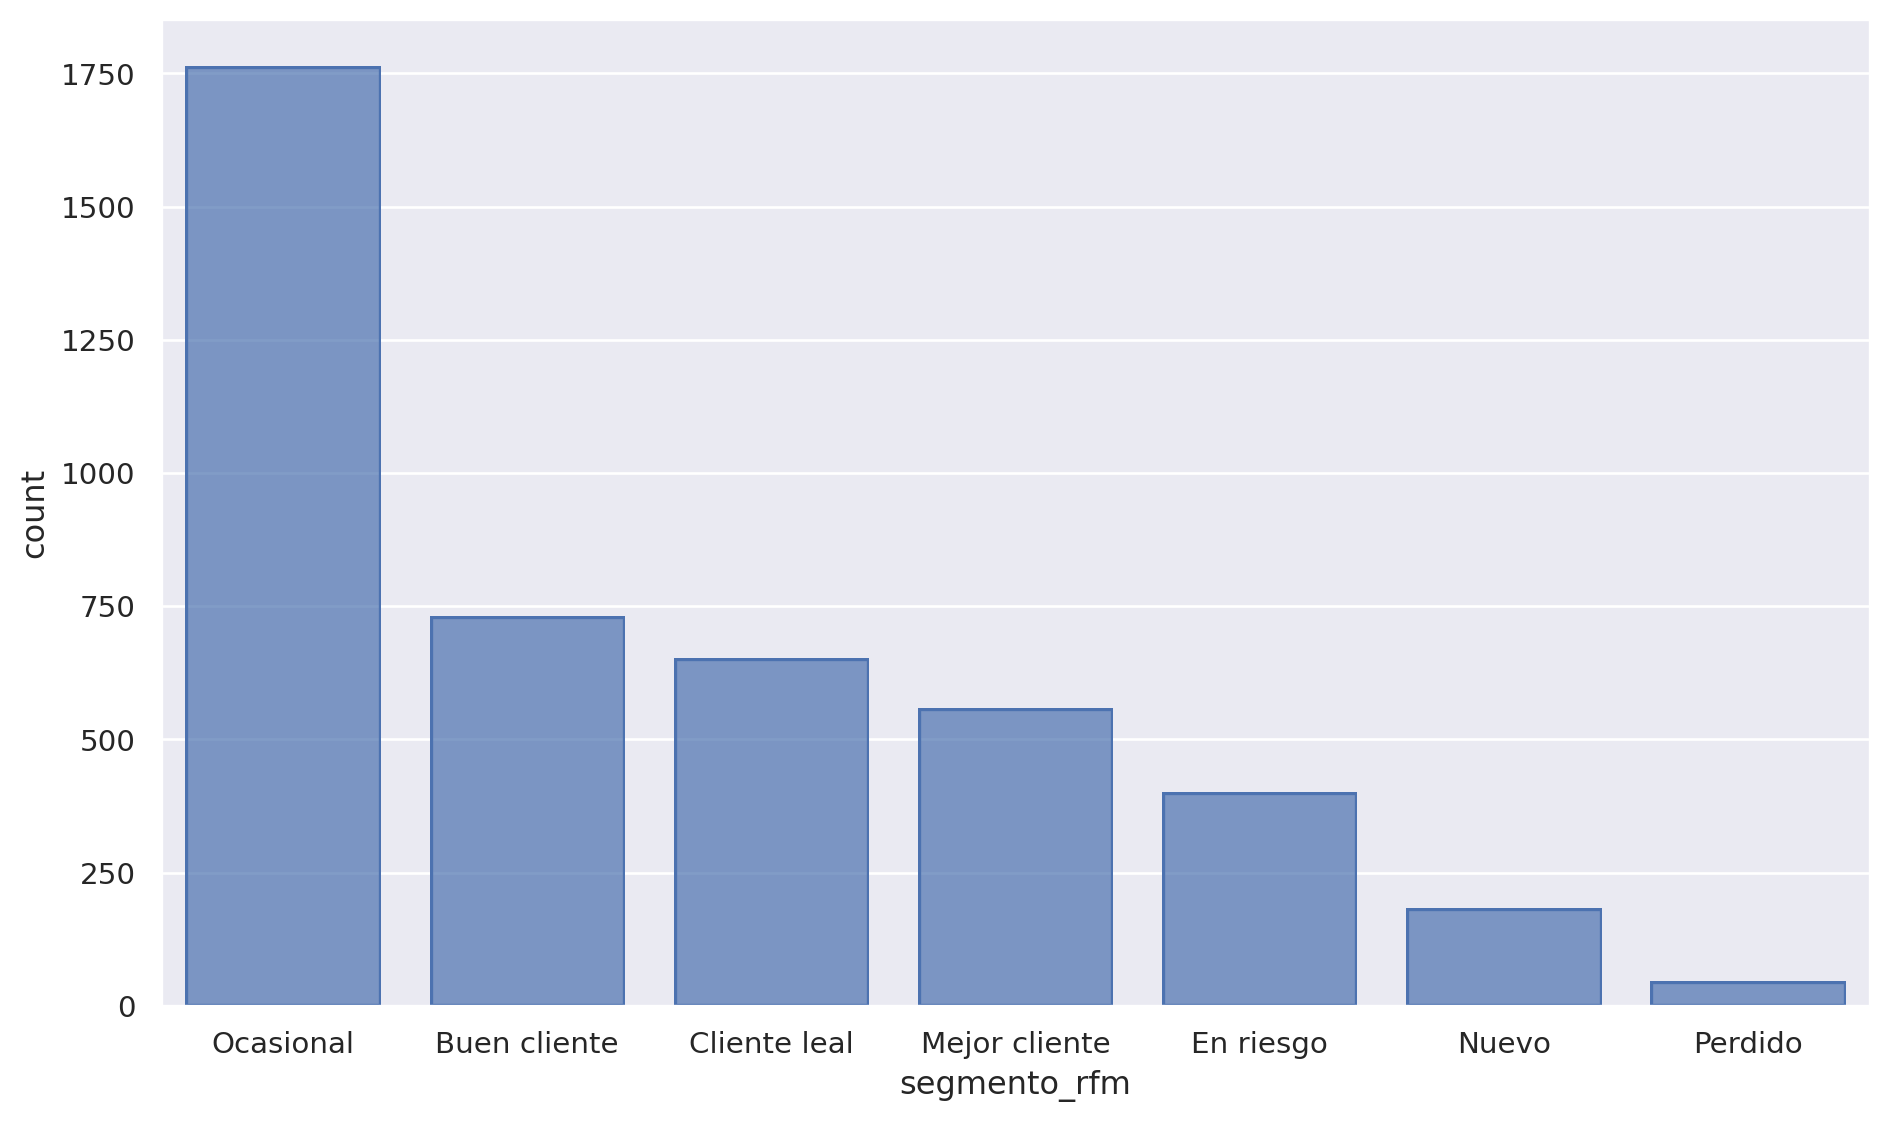

In [35]:
conteo = rfm_sin_desconocidos['segmento_rfm'].value_counts().reset_index()

(
    so.Plot(conteo, x='segmento_rfm', y='count')
    .add(so.Bar())
    .layout(size=(10,6))

)

Se pueden sacar algunas conclusiones a través de esta visualización, considerando que la elección de la clasificación fue arbitraria:

- Una proporción importante de los clientes pertenece a los segmentos "Buen cliente", "Cliente leal" y "Mejor cliente", lo que indica la existencia de una base de clientes con comportamientos favorables para el negocio.

- La mayor parte de los clientes pertenece al segmento "Ocasional", mientras que una cantidad considerable se encuentra "En riesgo". Esto representa una oportunidad para implementar estrategias que incentiven nuevas compras y permitan convertirlos en clientes recurrentes.

- El segmento de clientes nuevos representa una fracción reducida del total de clientes analizados.

- El segmento de clientes perdidos es reducido respecto al resto de las categorías. Este resultado es consistente con el análisis previo del porcentaje de clientes recurrentes, donde se observó una proporción elevada de clientes que vuelven a comprar.

##Ingresos por porcentaje de clientes

Se analiza la concentración de ingresos: qué porcentaje de la facturación total es generado por los clientes que más gastan?

Antes de responder esta pregunta, se calcula cuánto generaron los clientes desconocidos, tomando como referencia el cliente registrado que más generó.

In [36]:
rfm_sort_monetary = rfm.sort_values("monetary",ascending=False)

ingreso_desc = rfm_sort_monetary.iloc[0,:]["monetary"]
ingreso_mejor_cliente = rfm_sort_monetary.iloc[1,:]["monetary"]

print("El porcentaje de ingresos generados por clientes desconocidos respecto al mejor cliente fue un" , round(ingreso_desc/ingreso_mejor_cliente*100,2) , "%")

El porcentaje de ingresos generados por clientes desconocidos respecto al mejor cliente fue un 626.29 %


In [37]:
ingresos_sin_desconocidos = rfm_sort_monetary.iloc[1:,:].monetary.sum()

print("Los clientes desconocidos generan un",round(ingreso_desc/ingresos_sin_desconocidos*100,2),"% de los ingresos totales")

Los clientes desconocidos generan un 19.75 % de los ingresos totales


A continuación fueron analizados los ingresos sin considerar a los clientes desconocidos, evaluando los ingresos generado por el 5, 10 y 20% de los mejores clientes.

In [65]:
cant_clientes =len(rfm_sin_desconocidos)

porc_5 = int(np.floor(5*cant_clientes/100))
porc_10 = int(np.floor(10*cant_clientes/100))
porc_20 = int(np.floor(20*cant_clientes/100))

In [66]:
ingreso_total = ingresos_sin_desconocidos

ingreso_5_porc = rfm_sin_desconocidos.head(porc_5).monetary.sum()
ingreso_10_porc = rfm_sin_desconocidos.head(porc_10).monetary.sum()
ingreso_20_porc = rfm_sin_desconocidos.head(porc_20).monetary.sum()

print("Porcentaje de ingreso de los clientes del 5% que más generaron:",round(ingreso_5_porc/ingreso_total*100,2),"%")
print("Porcentaje de ingreso de los clientes del 10% que más generaron:",round(ingreso_10_porc/ingreso_total*100,2),"%")
print("Porcentaje de ingreso de los clientes del 20% que más generaron:",round(ingreso_20_porc/ingreso_total*100,2),"%")

Porcentaje de ingreso de los clientes del 5% que más generaron: 42.1 %
Porcentaje de ingreso de los clientes del 10% que más generaron: 52.8 %
Porcentaje de ingreso de los clientes del 20% que más generaron: 66.18 %


##Distribución de cantidad de compras

Se estudia como es la distribución de cantidades de compra (1 representa clientes que compraron una única vez, etc).

In [40]:
cantidad_frecuencias = frequency.iloc[1:].value_counts()
cantidad_frecuencias = cantidad_frecuencias.head(10)

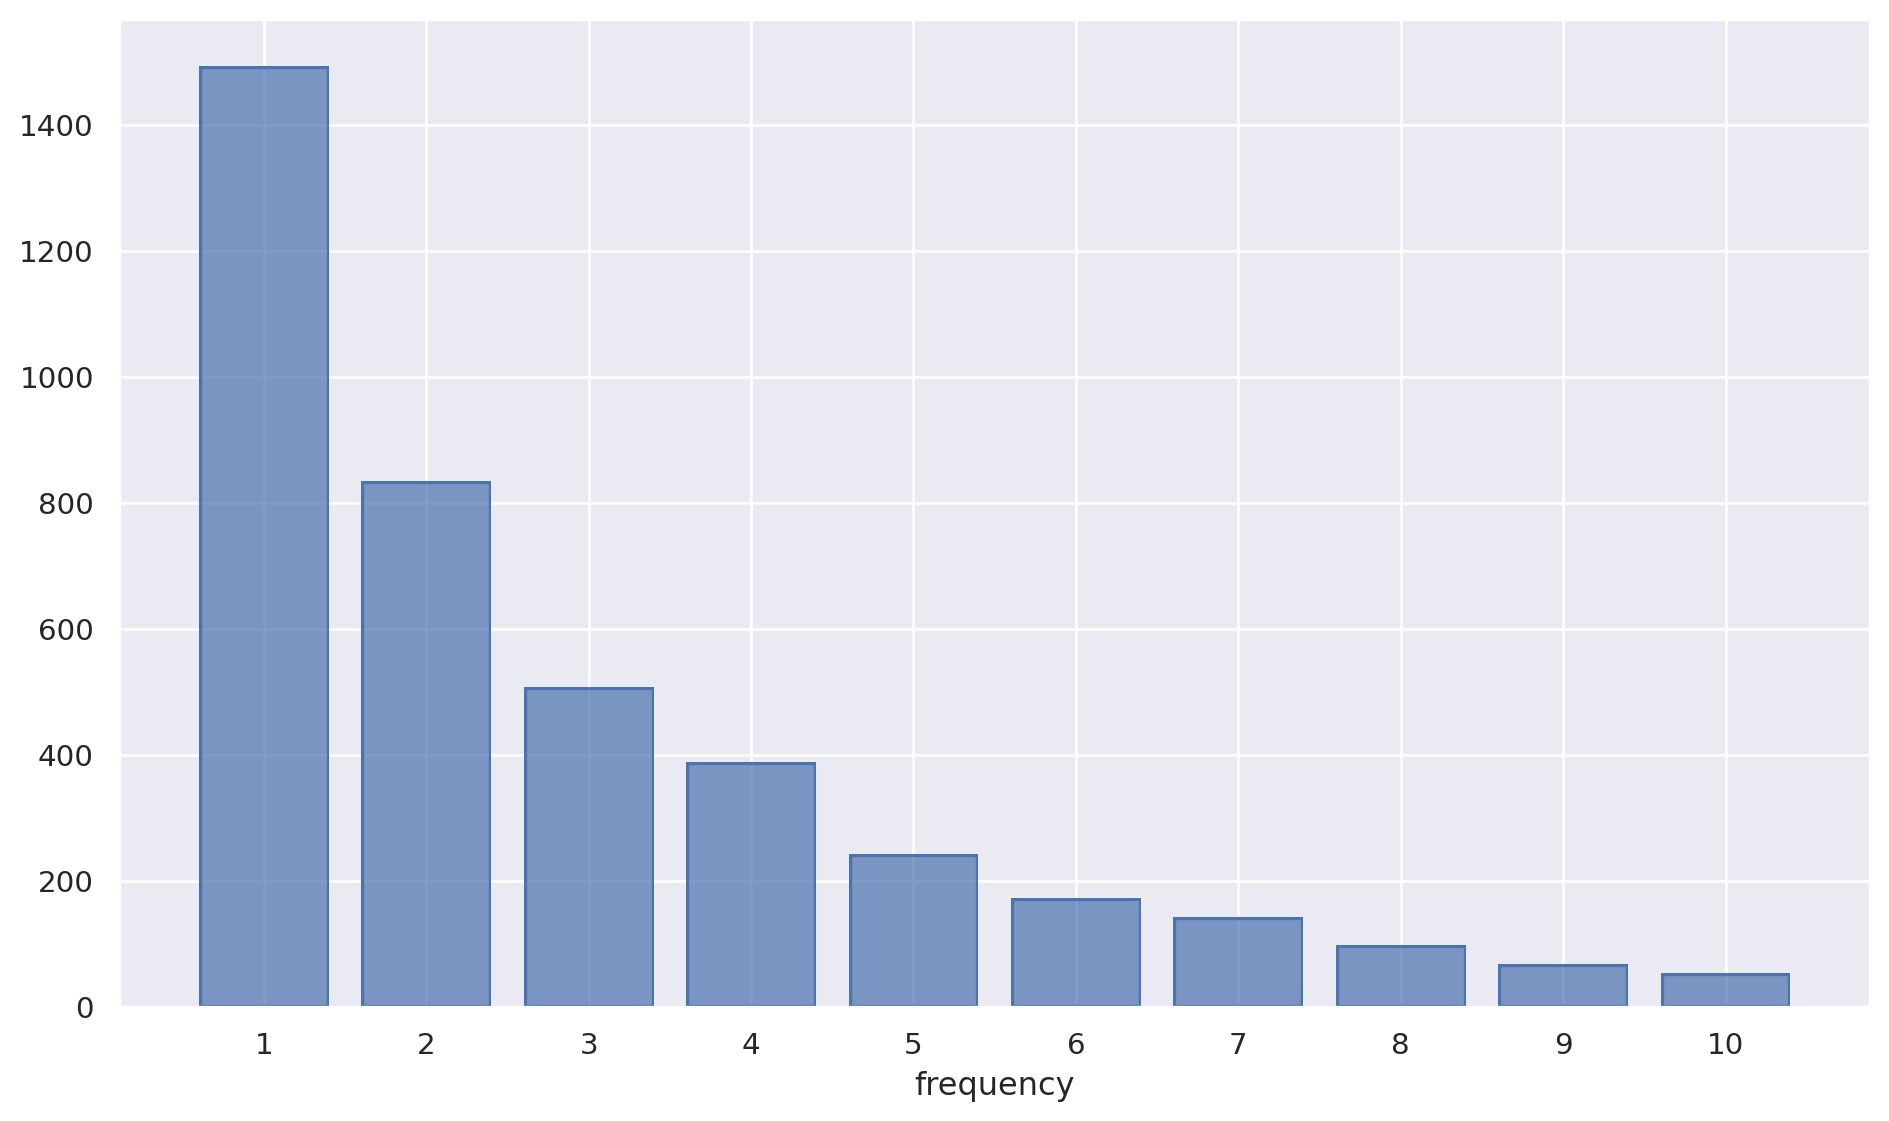

In [41]:
(
    so.Plot(x=cantidad_frecuencias.index,y=cantidad_frecuencias.values )
    .add(so.Bar())
    .layout(size=(10, 6))
    .scale(x=so.Continuous().tick(every=1))
)

Se puede ver un comportamiento exponencial de decrecimiento, ya que parece ser que la disminución de una frecuencia determinada a la siguiente sigue en muchos casos una tendencia similar.

Para verificar esta hipótesis, se aplica el logaritmo a los datos para ver si realmente el comportamiento es exponencial.

In [42]:
cantidad_frecuencias = np.log1p(cantidad_frecuencias)

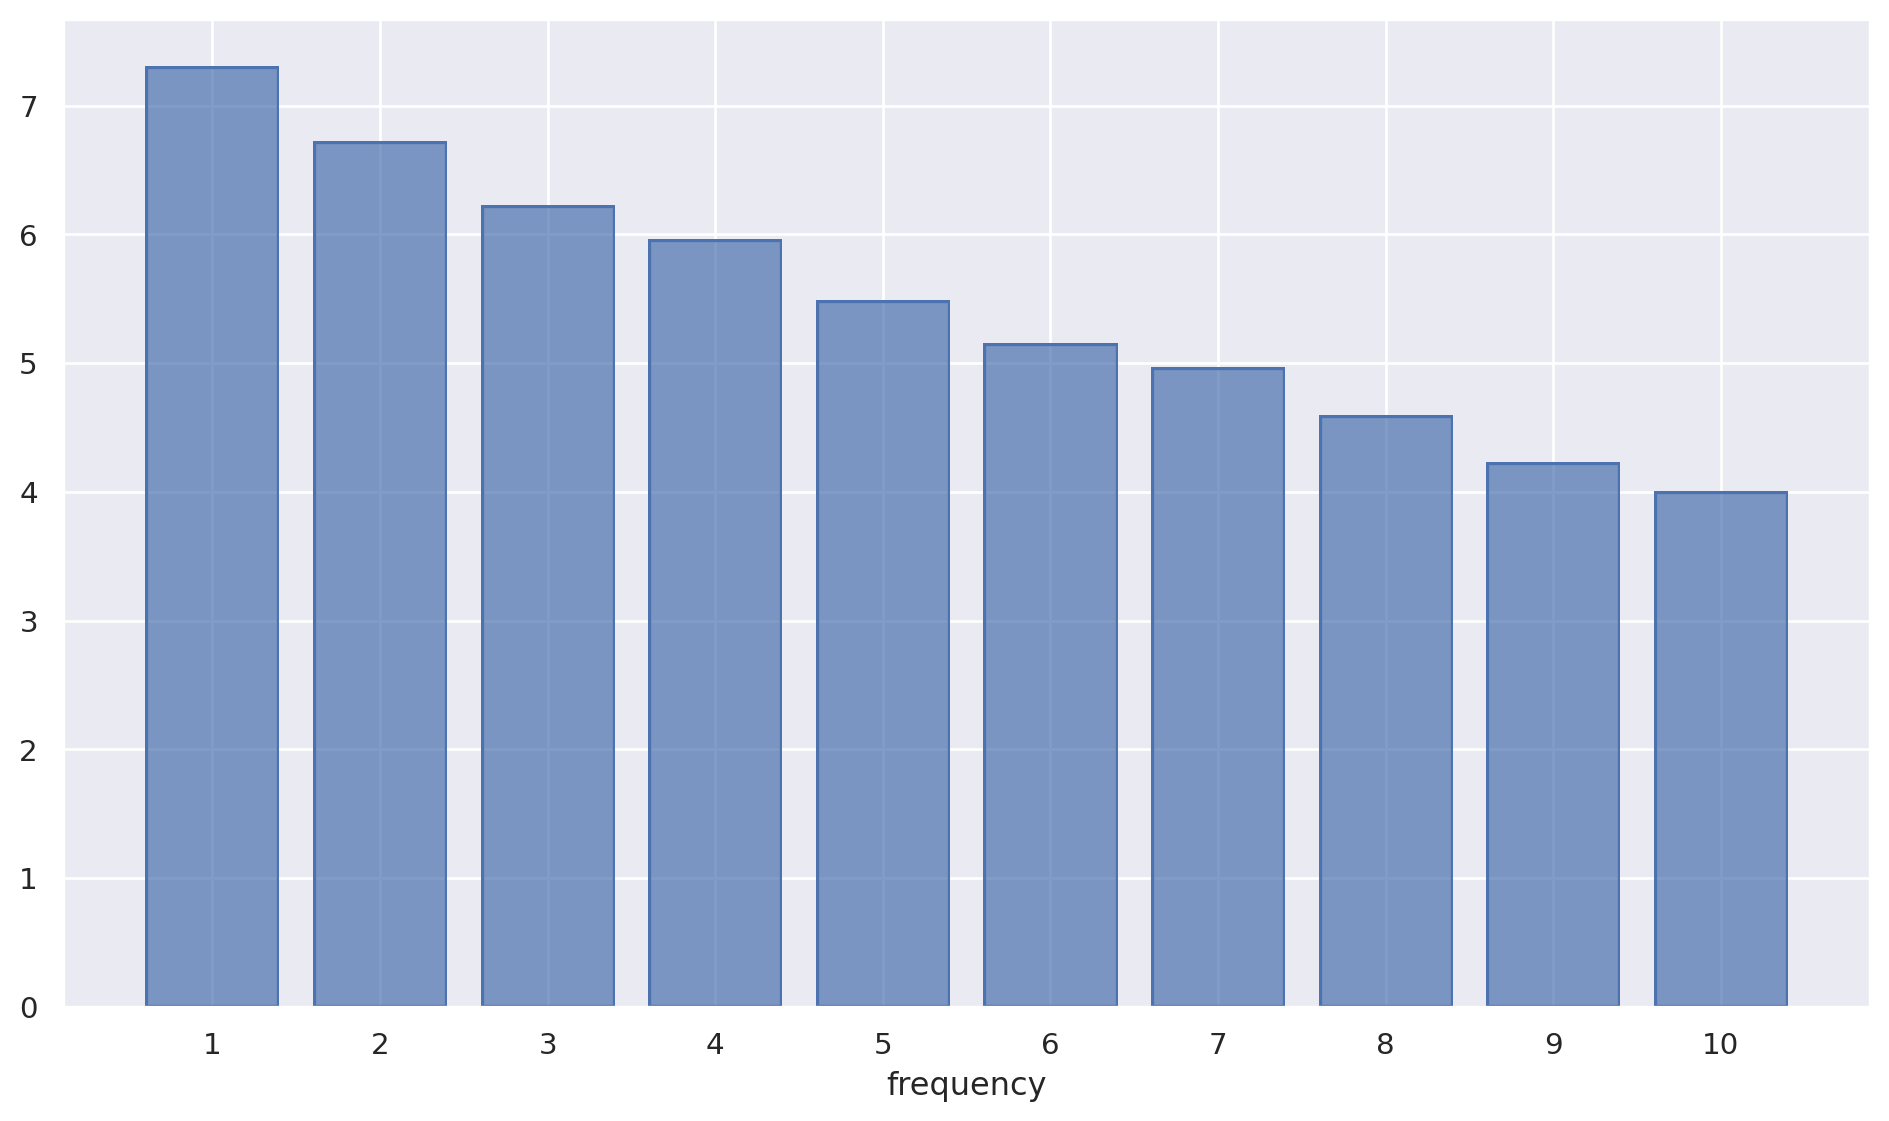

In [43]:
(
    so.Plot(x=cantidad_frecuencias.index,y=cantidad_frecuencias.values )
    .add(so.Bar())
    .layout(size=(10, 6))
    .scale(x=so.Continuous().tick(every=1))
)

En efecto, al aplicar una transformación logarítmica a la cantidad de clientes, la distribución presenta un comportamiento aproximadamente lineal. Esto sugiere que la cantidad de clientes disminuye de forma cercana a una ley exponencial a medida que aumenta la frecuencia de compra.

La pendiente observada es relativamente suave, lo que indica que la reducción en la cantidad de clientes entre frecuencias consecutivas es gradual y no abrupta.

La mayor parte de los clientes realiza pocas compras, mientras que el número de clientes disminuye progresivamente a medida que aumenta la frecuencia de compra.

#Conclusiones

El presente proyecto permitió recorrer el proceso completo de análisis de datos, desde la limpieza y preparación del conjunto de datos hasta la construcción de un dashboard interactivo y el estudio del comportamiento de los clientes mediante distintas técnicas de análisis exploratorio.

En primer lugar, el proceso de limpieza permitió detectar y tratar registros duplicados, clientes sin identificación, productos sin descripción y transacciones con cantidades o precios negativos. Si bien parte de estos registros puede responder a situaciones normales del negocio, como devoluciones o cancelaciones, también ponen de manifiesto la importancia de contar con procesos de registro y validación de datos más robustos, ya que la calidad de la información constituye la base de cualquier análisis posterior.

A partir del análisis realizado se observa que el negocio presenta indicadores favorables respecto al comportamiento de sus clientes. Aproximadamente dos tercios de ellos realizan compras recurrentes y una proporción importante pertenece a los segmentos de buenos clientes, clientes leales y mejores clientes, mientras que el porcentaje de clientes perdidos resulta reducido. Estos resultados sugieren un buen nivel de fidelización y una base de clientes relativamente estable.

Asimismo, el análisis permitió identificar que una parte importante de los ingresos se concentra en un grupo reducido de clientes, lo que resalta la importancia de conservar a aquellos compradores de mayor valor. Sin embargo, una fracción considerable de la facturación continúa distribuyéndose entre el resto de los clientes, lo que indica que el negocio no depende exclusivamente de unas pocas "ballenas", sino que mantiene una cartera relativamente diversificada.

Por otra parte, también se identificaron oportunidades de mejora. El segmento más numeroso corresponde a los clientes ocasionales y, además, se observa una cantidad significativa de clientes en riesgo. Por otro lado, el análisis conjunto de la frecuencia de compra y la recencia muestra que la mayoría de los clientes que realizaron una única compra terminan formando parte del grupo de clientes inactivos. En conjunto, estos resultados sugieren que uno de los principales desafíos del negocio consiste en lograr que los clientes que compran de manera ocasional o que hace un tiempo considerable no realizan compras vuelvan a comprar, así como incentivar una segunda compra en aquellos clientes que recién realizaron su primera adquisición, aumentando de este modo la probabilidad de fidelización.

Para alcanzar este objetivo, podrían implementarse acciones como promociones personalizadas, recomendaciones de productos basadas en compras anteriores, programas de fidelización, beneficios para segundas compras o encuestas de satisfacción que permitan comprender mejor las necesidades y preferencias de los clientes.

Finalmente, aunque el negocio presenta una buena retención de clientes, el porcentaje de clientes nuevos resulta relativamente reducido. Esto pone de manifiesto la importancia de complementar las estrategias de fidelización con acciones orientadas a la captación de nuevos compradores, mediante campañas de marketing, lanzamiento de nuevos productos, promociones para primeras compras o programas de recomendación entre clientes.

En conjunto, el análisis realizado permitió identificar tanto fortalezas como oportunidades de mejora y demuestra cómo el análisis de datos puede transformarse en una herramienta de apoyo para la toma de decisiones comerciales. A partir de la información disponible fue posible obtener una visión integral del negocio, comprender el comportamiento de los clientes y proponer acciones concretas orientadas a mejorar la fidelización, incrementar la captación de nuevos compradores y potenciar el crecimiento de la empresa.

Cabe destacar que las conclusiones obtenidas corresponden al período analizado y a las variables disponibles en el conjunto de datos. Incorporar información adicional, como se explicó en el objetivo del proyecto, permitiría realizar análisis aún más completos y desarrollar modelos predictivos en trabajos futuros, como por ejemplo estimar la probabilidad de abandono de un cliente, predecir el valor esperado de compras futuras o recomendar productos mediante técnicas de Machine Learning.

